# extract.ai — Recipe (YAML) Examples

This notebook covers `extract.ai` purely through **YAML recipes** — the
format most Wrangles users actually run in production via
`wrangles.recipe.run(...)`.

It mirrors the features shown in `extract_ai_user_guide.ipynb`, but every
example is a recipe string instead of a direct Python call:

1. Setup
2. Basic single-field extraction
3. Multiple output fields
4. Shorthand output formats (string / list)
5. Enum-constrained output
6. Numeric and array output types
7. Reasoning & verbosity controls (`gpt-5` family)
8. Threads, timeout, retries
9. Examples to guide the model
10. Error handling in a recipe
11. **Metrics comparison**: old (Chat Completions) vs new (Responses API) endpoint
12. **Metrics comparison**: model selection (`gpt-4.1-mini` vs `gpt-4o-mini` vs `gpt-5-mini`)
13. Quick reference

## 1. Setup

Recipes can reference secrets like the API key via `${VARIABLE}`
placeholders, which are filled in from environment variables or the
`variables=` argument to `recipe.run()`.

In [46]:
import os
import time
import pandas as pd
import wrangles
from wrangles import recipe

API_KEY = os.environ["OPENAI_API_KEY"]

# Recipes pick up ${OPENAI_API_KEY} from the environment automatically,
# but we also pass it explicitly via `variables=` for clarity.
variables = {"OPENAI_API_KEY": API_KEY}

## 2. Basic single-field extraction

The `extract.ai` wrangle works on an existing dataframe column (`data`
below). Pass a dataframe directly to `recipe.run()` — no `read`/`write`
steps are needed; the resulting dataframe is returned.

In [47]:
recipe_basic = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
      output:
        length:
          type: string
          description: Any length measurement found in the text, e.g. 25mm
'''

df = pd.DataFrame({
    "data": [
        "wrench 25mm",
        "6m cable",
        "screwdriver 3mm",
    ]
})

result = recipe.run(recipe_basic, variables=variables, dataframe=df)
result

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length :: 1.952s


,data,length
0,wrench 25mm,25mm
1,6m cable,6m
2,screwdriver 3mm,3mm


## 3. Multiple output fields

A single `extract.ai` step can populate several new columns in one call.

In [48]:
recipe_multi = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
      output:
        length:
          type: string
          description: Any length measurement found in the text, e.g. 25mm
        item_type:
          type: string
          description: The type of item described, e.g. wrench, cable, screwdriver
'''

df = pd.DataFrame({
    "data": [
        "wrench 25mm",
        "6m cable",
        "screwdriver 3mm",
    ]
})

result = recipe.run(recipe_multi, variables=variables, dataframe=df)
result

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length, item_type :: 1.322s


,data,length,item_type
0,wrench 25mm,25mm,wrench
1,6m cable,6m,cable
2,screwdriver 3mm,3mm,screwdriver


## 4. Shorthand output formats

`output` doesn't have to be a fully-specified object — a plain string
description, or a list of column names / single-key mappings, both work as
shorthand for "create this column with this description".

In [49]:
# Output as a plain description string -> column named after the input column
recipe_string_output = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
      output: >-
        Any length measurement found in the text, e.g. 25mm
'''

df = pd.DataFrame({"data": ["wrench 25mm", "6m cable", "screwdriver 3mm"]})
result = recipe.run(recipe_string_output, variables=variables, dataframe=df)
result

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Any length measurement found in the text, e.g. 25mm :: 1.392s


,data,"Any length measurement found in the text, e.g. 25mm"
0,wrench 25mm,25mm
1,6m cable,6m
2,screwdriver 3mm,3mm


In [50]:
# Output as a list of single-key mappings -> one column per entry
recipe_list_output = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
      output:
        - length: Any length measurement found in the text, e.g. 25mm
        - item_type: The type of item described, e.g. wrench, cable, screwdriver
'''

df = pd.DataFrame({"data": ["wrench 25mm", "6m cable", "screwdriver 3mm"]})
result = recipe.run(recipe_list_output, variables=variables, dataframe=df)
result

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length, item_type :: 2.384s


,data,length,item_type
0,wrench 25mm,25mm,wrench
1,6m cable,6m,cable
2,screwdriver 3mm,3mm,screwdriver


## 5. Enum-constrained output

Add an `enum` list to constrain the model to a fixed set of values —
useful for sentiment, categories, classification labels, etc.

In [51]:
recipe_enum = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
      output:
        sentiment:
          type: string
          description: The sentiment of the review
          enum:
            - positive
            - negative
            - neutral
'''

df = pd.DataFrame({
    "data": [
        "The best purchase I've made all year!",
        "Broke after a single use, total waste of money.",
        "It's fine, does what it says on the box.",
    ]
})

result = recipe.run(recipe_enum, variables=variables, dataframe=df)
result

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> sentiment :: 2.340s


,data,sentiment
0,The best purchase I've made all year!,positive
1,"Broke after a single use, total waste of money.",negative
2,"It's fine, does what it says on the box.",neutral


## 6. Numeric and array output types

`output` fields can be typed as `number`/`integer` (returned as actual
numeric values, not strings) or `array` (returned as Python lists).

In [52]:
recipe_numeric = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
      output:
        item_count:
          type: integer
          description: The total number of items mentioned in the text
        ingredients:
          type: array
          description: A list of every distinct ingredient mentioned
'''

df = pd.DataFrame({
    "data": [
        "I bought 3 apples, 2 bananas and a loaf of bread",
        "The recipe needs flour, sugar, eggs and butter",
    ]
})

result = recipe.run(recipe_numeric, variables=variables, dataframe=df)
result

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> item_count, ingredients :: 3.273s


,data,item_count,ingredients
0,"I bought 3 apples, 2 bananas and a loaf of bread",6,"[apples, bananas, bread]"
1,"The recipe needs flour, sugar, eggs and butter",4,"[flour, sugar, eggs, butter]"


In [53]:
print(result["item_count"].tolist(), [type(x) for x in result["item_count"]])
print(result["ingredients"].tolist(), [type(x) for x in result["ingredients"]])

[6, 4] [<class 'int'>, <class 'int'>]
[['apples', 'bananas', 'bread'], ['flour', 'sugar', 'eggs', 'butter']] [<class 'list'>, <class 'list'>]


## 7. Reasoning & verbosity controls (`gpt-5` family)

For reasoning-capable models (`gpt-5*`, `o1`, `o3`, `o4`), a recipe can set
`reasoning.effort` and `text.verbosity` directly.

For older, non-reasoning models (e.g. `gpt-4o-mini`, `gpt-4.1-mini`), the
OpenAI API rejects these parameters outright. For backwards compatibility,
`extract.ai` now **skips** `reasoning`/`verbosity` for models that don't
support them, logs a warning via the `wrangles.extract` logger, and still
completes the request successfully.

In [54]:
recipe_reasoning = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
      model: gpt-5-mini
      reasoning:
        effort: low
      verbosity: low
      output:
        length:
          type: string
          description: Any length measurement found in the text, e.g. 25mm
'''

df = pd.DataFrame({"data": ["wrench 25mm", "6m cable"]})
result = recipe.run(recipe_reasoning, variables=variables, dataframe=df)
result

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length :: 1.893s


,data,length
0,wrench 25mm,25mm
1,6m cable,6m


In [55]:
import logging

logging.basicConfig(level=logging.WARNING)

# A pre-gpt5 model with reasoning/verbosity set in the recipe.
# These are not supported by gpt-4o-mini, so they are skipped
# (with a warning logged) and the request still succeeds.
recipe_reasoning_pre_gpt5 = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
      model: gpt-4o-mini
      reasoning:
        effort: low
      verbosity: low
      output:
        length:
          type: string
          description: Any length measurement found in the text, e.g. 25mm
'''

df = pd.DataFrame({"data": ["wrench 25mm", "6m cable"]})
result = recipe.run(recipe_reasoning_pre_gpt5, variables=variables, dataframe=df)
result

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length :: 2.562s


,data,length
0,wrench 25mm,25mm
1,6m cable,6m


### 7.1 Reasoning & verbosity on complex, multi-attribute data

The effect of `reasoning.effort` and `verbosity` is most visible on harder
extraction tasks — e.g. pulling several specific attributes out of a dense
technical part description. Below, the same complex input and output schema
are run multiple times with `gpt-5-mini`, varying only `reasoning.effort`
and only `verbosity`.

In [56]:
complex_df = pd.DataFrame({
    "data": [
        (
            "6 inch 150# ANSI raised face weld neck flange, "
            "carbon steel ASTM A105, schedule 40, ASME B16.5, "
            "manufactured by Acme Flange Co., part number AFC-6150-WN-A105"
        ),
    ],
})

complex_recipe_template = '''
wrangles:
  - extract.ai:
      api_key: ${{OPENAI_API_KEY}}
      model: gpt-5-mini
      timeout: 90
      retries: 2
      {extra_settings}
      output:
        Size:
          type: string
          description: The nominal pipe size of the flange
        PressureClass:
          type: string
          description: The ANSI/ASME pressure class rating
        Material:
          type: string
          description: The material specification of the flange
        FlangeType:
          type: string
          description: The type of flange, e.g. weld neck, slip on, blind
        Manufacturer:
          type: string
          description: The company that manufactures the part
        PartNumber:
          type: string
          description: The manufacturer's part number for the item
'''

def run_complex(extra_settings: str) -> dict:
    recipe_yaml = complex_recipe_template.format(extra_settings=extra_settings)
    start = time.time()
    out = recipe.run(recipe_yaml, variables=variables, dataframe=complex_df.copy())
    elapsed = time.time() - start
    row = out.iloc[0]
    return {
        "elapsed_s": round(elapsed, 2),
        "Size": row["Size"],
        "PressureClass": row["PressureClass"],
        "Material": row["Material"],
        "FlangeType": row["FlangeType"],
        "Manufacturer": row["Manufacturer"],
        "PartNumber": row["PartNumber"],
    }

#### Reasoning effort: `low` vs `medium` vs `high`

All three should correctly extract every field from the complex
description; higher effort levels generally take longer (more internal
reasoning tokens) but can be more reliable on harder/ambiguous inputs.

In [57]:
reasoning_results = []
for effort in ["low", "medium", "high"]:
    extra_settings = f"reasoning:\n        effort: {effort}"
    row = run_complex(extra_settings)
    row["reasoning_effort"] = effort
    reasoning_results.append(row)

reasoning_df = pd.DataFrame(reasoning_results).set_index("reasoning_effort")
reasoning_df

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Size, PressureClass, Material, FlangeType, Manufacturer, PartNumber :: 3.029s
INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Size, PressureClass, Material, FlangeType, Manufacturer, PartNumber :: 5.029s
INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Size, PressureClass, Material, FlangeType, Manufacturer, PartNumber :: 11.057s


,elapsed_s,Size,PressureClass,Material,FlangeType,Manufacturer,PartNumber
reasoning_effort,,,,,,,
low,3.03,6 inch,150#,carbon steel ASTM A105,raised face weld neck,Acme Flange Co.,AFC-6150-WN-A105
medium,5.03,6 inch,150#,carbon steel ASTM A105,raised face weld neck,Acme Flange Co.,AFC-6150-WN-A105
high,11.06,6 inch,150#,carbon steel ASTM A105,raised face weld neck,Acme Flange Co.,AFC-6150-WN-A105


#### Verbosity: `low` vs `medium` vs `high`

`verbosity` controls how much explanatory text the model produces
internally before filling in the structured output — it does not change
the *shape* of `output`, but can affect accuracy and latency on complex
inputs.

In [58]:
verbosity_results = []
for verbosity in ["low", "medium", "high"]:
    extra_settings = f"verbosity: {verbosity}"
    row = run_complex(extra_settings)
    row["verbosity"] = verbosity
    verbosity_results.append(row)

verbosity_df = pd.DataFrame(verbosity_results).set_index("verbosity")
verbosity_df

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Size, PressureClass, Material, FlangeType, Manufacturer, PartNumber :: 11.999s
INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Size, PressureClass, Material, FlangeType, Manufacturer, PartNumber :: 3.337s
INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Size, PressureClass, Material, FlangeType, Manufacturer, PartNumber :: 3.745s


,elapsed_s,Size,PressureClass,Material,FlangeType,Manufacturer,PartNumber
verbosity,,,,,,,
low,12.01,6 inch,150#,carbon steel ASTM A105,weld neck,Acme Flange Co.,AFC-6150-WN-A105
medium,3.34,6 inch,150#,carbon steel ASTM A105,raised face weld neck flange,Acme Flange Co.,AFC-6150-WN-A105
high,3.75,6 inch,150# ANSI,carbon steel ASTM A105,raised face weld neck flange,Acme Flange Co.,AFC-6150-WN-A105


### 7.2 A second complex example: ambiguous pump spec sheet

A different domain and a trickier input — the discharge size is mentioned
twice (the pump's native NPT size vs. an optional adapter size), which
requires the model to pick the *correct* one rather than just the first
number it sees.

In [59]:
pump_df = pd.DataFrame({
    "data": [
        (
            "Submersible centrifugal pump, 2 HP, single phase 230V, "
            "1.5 inch NPT discharge, max flow approx. 80 GPM at 40 ft head, "
            "304 stainless steel impeller, Model SP-2000-SS, by HydroTech Pumps. "
            "Note: also compatible with optional 1.25 inch reducing adapters."
        ),
    ],
})

pump_recipe_template = '''
wrangles:
  - extract.ai:
      api_key: ${{OPENAI_API_KEY}}
      model: gpt-5-mini
      timeout: 90
      retries: 2
      {extra_settings}
      output:
        Power:
          type: string
          description: The motor power rating of the pump, including units
        Voltage:
          type: string
          description: The electrical voltage and phase the pump runs on
        DischargeSize:
          type: string
          description: >-
            The pump's native discharge connection size, NOT any
            optional adapter size
        MaxFlow:
          type: string
          description: The maximum flow rate, including units
        MaxHead:
          type: string
          description: The maximum head/pressure rating, including units
        ImpellerMaterial:
          type: string
          description: The material the impeller is made from
        Model:
          type: string
          description: The manufacturer's model number
        Manufacturer:
          type: string
          description: The company that manufactures the pump
'''

def run_pump(extra_settings: str) -> dict:
    recipe_yaml = pump_recipe_template.format(extra_settings=extra_settings)
    start = time.time()
    out = recipe.run(recipe_yaml, variables=variables, dataframe=pump_df.copy())
    elapsed = time.time() - start
    row = out.iloc[0]
    return {
        "elapsed_s": round(elapsed, 2),
        "Power": row["Power"],
        "Voltage": row["Voltage"],
        "DischargeSize": row["DischargeSize"],
        "MaxFlow": row["MaxFlow"],
        "MaxHead": row["MaxHead"],
        "ImpellerMaterial": row["ImpellerMaterial"],
        "Model": row["Model"],
        "Manufacturer": row["Manufacturer"],
    }

#### Reasoning effort: `low` vs `medium` vs `high`

Watch `DischargeSize` in particular — picking `1.5 inch` (the native
discharge) over `1.25 inch` (the optional adapter) requires reading the
whole sentence rather than grabbing the first size-like value.

In [60]:
pump_reasoning_results = []
for effort in ["low", "medium", "high"]:
    extra_settings = f"reasoning:\n        effort: {effort}"
    row = run_pump(extra_settings)
    row["reasoning_effort"] = effort
    pump_reasoning_results.append(row)

pump_reasoning_df = pd.DataFrame(pump_reasoning_results).set_index("reasoning_effort")
pump_reasoning_df

INFO:root:: Wrangling :: extract.ai :: Starting


INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Power, Voltage, DischargeSize, MaxFlow, MaxHead, ImpellerMaterial, Model, Manufacturer :: 2.958s
INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Power, Voltage, DischargeSize, MaxFlow, MaxHead, ImpellerMaterial, Model, Manufacturer :: 6.772s
INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Power, Voltage, DischargeSize, MaxFlow, MaxHead, ImpellerMaterial, Model, Manufacturer :: 9.373s


,elapsed_s,Power,Voltage,DischargeSize,MaxFlow,MaxHead,ImpellerMaterial,Model,Manufacturer
reasoning_effort,,,,,,,,,
low,2.97,2 HP,single phase 230V,1.5 inch NPT,approx. 80 GPM,40 ft head,304 stainless steel,SP-2000-SS,HydroTech Pumps
medium,6.78,2 HP,single phase 230V,1.5 inch NPT,approx. 80 GPM,40 ft head,304 stainless steel,SP-2000-SS,HydroTech Pumps
high,9.38,2 HP,single phase 230V,1.5 inch NPT,approx. 80 GPM,40 ft head,304 stainless steel,SP-2000-SS,HydroTech Pumps


#### Verbosity: `low` vs `medium` vs `high`

Same pump description, same output schema, varying only `verbosity`.

In [61]:
pump_verbosity_results = []
for verbosity in ["low", "medium", "high"]:
    extra_settings = f"verbosity: {verbosity}"
    row = run_pump(extra_settings)
    row["verbosity"] = verbosity
    pump_verbosity_results.append(row)

pump_verbosity_df = pd.DataFrame(pump_verbosity_results).set_index("verbosity")
pump_verbosity_df

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Power, Voltage, DischargeSize, MaxFlow, MaxHead, ImpellerMaterial, Model, Manufacturer :: 3.306s
INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Power, Voltage, DischargeSize, MaxFlow, MaxHead, ImpellerMaterial, Model, Manufacturer :: 2.983s
INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> Power, Voltage, DischargeSize, MaxFlow, MaxHead, ImpellerMaterial, Model, Manufacturer :: 3.064s


,elapsed_s,Power,Voltage,DischargeSize,MaxFlow,MaxHead,ImpellerMaterial,Model,Manufacturer
verbosity,,,,,,,,,
low,3.31,2 HP,single phase 230V,1.5 inch NPT,approx. 80 GPM,40 ft head,304 stainless steel,SP-2000-SS,HydroTech Pumps
medium,2.99,2 HP,single phase 230V,1.5 inch NPT,approx. 80 GPM,40 ft head,304 stainless steel,SP-2000-SS,HydroTech Pumps
high,3.07,2 HP,single phase 230V,1.5 inch NPT,approx. 80 GPM,40 ft,304 stainless steel,SP-2000-SS,HydroTech Pumps


## 8. Threads, timeout, retries

For larger batches, `threads` controls parallel API calls; `timeout` and
`retries` control how long each call waits and how many times a failed
call is retried.

In [62]:
recipe_perf = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
      threads: 8
      timeout: 60
      retries: 1
      output:
        length:
          type: string
          description: Any length measurement found in the text, e.g. 25mm
'''

df = pd.DataFrame({
    "data": [f"part {i}: bolt {5 + i}mm" for i in range(10)]
})

start = time.time()
result = recipe.run(recipe_perf, variables=variables, dataframe=df)
elapsed = time.time() - start

print(f"Processed {len(df)} rows in {elapsed:.2f}s with threads=8")
result

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length :: 15.814s


Processed 10 rows in 15.82s with threads=8


,data,length
0,part 0: bolt 5mm,5mm
1,part 1: bolt 6mm,6mm
2,part 2: bolt 7mm,7mm
3,part 3: bolt 8mm,8mm
4,part 4: bolt 9mm,9mm
5,part 5: bolt 10mm,10mm
6,part 6: bolt 11mm,11mm
7,part 7: bolt 12mm,12mm
8,part 8: bolt 13mm,13mm
9,part 9: bolt 14mm,14mm


## 9. Examples to guide the model

`examples` on a field nudge the model toward a particular output style or
unit format, without being included in the strict JSON schema sent to
OpenAI (they're folded into the instructions instead).

In [63]:
recipe_examples = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
      output:
        length:
          type: string
          description: Any length measurement found in the text
          examples:
            - 25mm
            - 1.5m
'''

df = pd.DataFrame({"data": ["a six metre cable", "a twenty five millimetre wrench"]})
result = recipe.run(recipe_examples, variables=variables, dataframe=df)
result

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length :: 1.883s


,data,length
0,a six metre cable,six metre
1,a twenty five millimetre wrench,25 mm


## 10. Error handling in a recipe

Configuration errors (missing `output`, invalid `model_id`/`api_key`
combination, bad schema types) are raised immediately when the recipe runs.
Per-row errors (model rejects a request, timeout) are returned as
descriptive strings in the output column instead of crashing the recipe.

In [64]:
# Configuration error: no output specified -> raised immediately
bad_recipe = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
'''

df = pd.DataFrame({"data": ["wrench 25mm"]})

try:
    recipe.run(bad_recipe, variables=variables, dataframe=df)
except Exception as e:
    print(f"{type(e).__name__}: {e}")

INFO:root:: Wrangling :: extract.ai :: Starting


ValueError: ERROR IN WRANGLE #1 extract.ai - output or model_id must be specified.


In [65]:
# Per-row error: an invalid model name -> error string per field, recipe still completes
recipe_bad_model = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
      model: gpt-totally-fake-model
      retries: 0
      output:
        length:
          type: string
          description: Any length measurement found in the text
'''

df = pd.DataFrame({"data": ["wrench 25mm", "6m cable"]})
result = recipe.run(recipe_bad_model, variables=variables, dataframe=df)
result

INFO:root:: Wrangling :: extract.ai :: Starting
ERROR:wrangles.openai_responses:Final OpenAI API error: {"attempt": 1, "code": "model_not_found", "endpoint": "responses", "message": "The requested model 'gpt-totally-fake-model' does not exist.", "model": "gpt-totally-fake-model", "param": "model", "rate_limit_headers": {"x-request-id": "req_29fe4cb4893048e8888c2ecf8e81deef"}, "request_id": "req_29fe4cb4893048e8888c2ecf8e81deef", "status_code": 400, "type": "invalid_request_error"}
ERROR:wrangles.openai_responses:Final OpenAI API error: {"attempt": 1, "code": "model_not_found", "endpoint": "responses", "message": "The requested model 'gpt-totally-fake-model' does not exist.", "model": "gpt-totally-fake-model", "param": "model", "rate_limit_headers": {"x-request-id": "req_18df49a7254e45258b4f63f241e2cce2"}, "request_id": "req_18df49a7254e45258b4f63f241e2cce2", "status_code": 400, "type": "invalid_request_error"}
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length :: 5.255s

,data,length
0,wrench 25mm,OpenAI API error | status=400 | model=gpt-tota...
1,6m cable,OpenAI API error | status=400 | model=gpt-tota...



## 11. Metrics comparison: old vs new endpoint

Same recipe, same data, two endpoints:

- **New (default)**: `https://api.openai.com/v1/responses` (Responses API, omitted = default)
- **Old**: `https://api.openai.com/v1/chat/completions` (legacy function-calling path,
  set via `url`)

We compare **accuracy against a known ground truth** and **wall-clock time**.


In [66]:

ground_truth = ["25mm", "6m", "3mm", "10cm", "1.5m"]

df = pd.DataFrame({
    "data": [
        "wrench 25mm",
        "6m cable",
        "screwdriver 3mm",
        "bracket 10cm",
        "rope 1.5m long",
    ]
})

recipe_template = '''
wrangles:
  - extract.ai:
      api_key: ${{OPENAI_API_KEY}}
      model: gpt-4.1-mini
      seed: 1
      retries: 2
      {url_line}
      output:
        length:
          type: string
          description: >-
            Any length measurement found in the text,
            such as cm, m, ft, mm, etc.
'''

endpoints = {
    "new (responses)": "",
    "old (chat completions)": "url: https://api.openai.com/v1/chat/completions",
}

metrics = []
for label, url_line in endpoints.items():
    recipe_yaml = recipe_template.format(url_line=url_line)

    start = time.time()
    out = recipe.run(recipe_yaml, variables=variables, dataframe=df.copy())
    elapsed = time.time() - start

    accuracy = sum(
        str(out["length"][i]).replace(" ", "") == ground_truth[i].replace(" ", "")
        for i in range(len(ground_truth))
    ) / len(ground_truth)

    metrics.append({
        "endpoint": label,
        "accuracy": accuracy,
        "elapsed_s": round(elapsed, 2),
        "results": out["length"].tolist(),
    })

metrics_df = pd.DataFrame(metrics)
metrics_df


INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length :: 3.089s
INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length :: 1.422s


,endpoint,accuracy,elapsed_s,results
0,new (responses),1.0,3.10,"[25mm, 6m, 3mm, 10cm, 1.5m]"
1,old (chat completions),1.0,1.44,"[25mm, 6m, 3mm, 10cm, 1.5m]"


## 12. Metrics comparison: model selection

Same recipe and data, varying only `model`. Useful for picking the cheapest
model that still meets an accuracy bar for a given extraction task.

In [67]:
models = ["gpt-4.1-mini", "gpt-4o-mini", "gpt-5-mini"]

recipe_model_template = '''
wrangles:
  - extract.ai:
      api_key: ${{OPENAI_API_KEY}}
      model: {model}
      seed: 1
      retries: 2
      output:
        length:
          type: string
          description: >-
            Any length measurement found in the text,
            such as cm, m, ft, mm, etc.
'''

model_metrics = []
for model in models:
    recipe_yaml = recipe_model_template.format(model=model)

    start = time.time()
    out = recipe.run(recipe_yaml, variables=variables, dataframe=df.copy())
    elapsed = time.time() - start

    accuracy = sum(
        str(out["length"][i]).replace(" ", "") == ground_truth[i].replace(" ", "")
        for i in range(len(ground_truth))
    ) / len(ground_truth)

    model_metrics.append({
        "model": model,
        "accuracy": accuracy,
        "elapsed_s": round(elapsed, 2),
        "results": out["length"].tolist(),
    })

model_metrics_df = pd.DataFrame(model_metrics)
model_metrics_df

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length :: 2.165s
INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length :: 2.910s
INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length :: 2.238s


,model,accuracy,elapsed_s,results
0,gpt-4.1-mini,1.0,2.17,"[25mm, 6m, 3mm, 10cm, 1.5m]"
1,gpt-4o-mini,1.0,2.92,"[25mm, 6m, 3mm, 10cm, 1.5m]"
2,gpt-5-mini,1.0,2.24,"[25mm, 6m, 3mm, 10cm, 1.5m]"


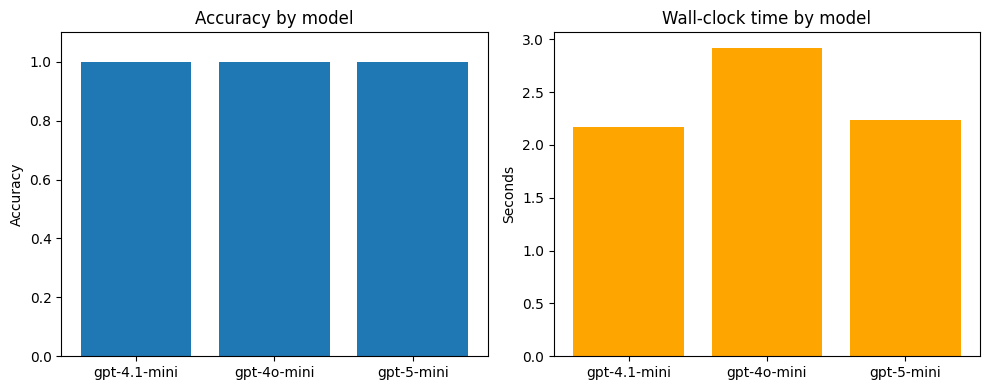

In [68]:
# Quick visual comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(model_metrics_df["model"], model_metrics_df["accuracy"])
axes[0].set_title("Accuracy by model")
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Accuracy")

axes[1].bar(model_metrics_df["model"], model_metrics_df["elapsed_s"], color="orange")
axes[1].set_title("Wall-clock time by model")
axes[1].set_ylabel("Seconds")

plt.tight_layout()
plt.show()

## 13. Rate-limit examples (recipes)

`extract.ai` has built-in rate-limit diagnostics and retry handling. Two
environment variables control the optional headroom-logging feature, and
the `retries`/`url` recipe options control retry behaviour. This section
covers both with real recipe runs.

| Env var | Purpose | Default |
|---|---|---|
| `WRANGLES_OPENAI_LOG_RATE_LIMITS` | Set to `true` to emit periodic `openai_rate_limit_summary` log lines from `wrangles.openai_responses` | off |
| `WRANGLES_OPENAI_LOG_EVERY` | How many successful responses between summary log lines | `100` |

### 13.1 Monitoring rate-limit headroom from a recipe

Set the two environment variables and turn on logging *before* calling
`recipe.run()`. No special recipe syntax is needed — the same
`extract.ai` wrangle is used as in the earlier sections.

In [69]:
import json
import logging

# Required env vars for headroom logging
os.environ["WRANGLES_OPENAI_LOG_RATE_LIMITS"] = "true"
os.environ["WRANGLES_OPENAI_LOG_EVERY"] = "1"


class ReadableRateLimitFormatter(logging.Formatter):
    """Pretty-print the openai_rate_limit_summary JSON log lines."""

    def format(self, record):
        message = record.getMessage()
        try:
            data = json.loads(message)
        except (TypeError, ValueError):
            return super().format(record)

        if data.get("event") != "openai_rate_limit_summary":
            return super().format(record)

        return (
            f"[rate limit] model={data.get('model')} ({data.get('endpoint')})\n"
            f"  responses so far     : {data.get('responses')}\n"
            f"  requests remaining   : {data.get('min_remaining_requests')}"
            f" (resets in {data.get('latest_reset_requests')})\n"
            f"  tokens remaining     : {data.get('min_remaining_tokens')}"
            f" (resets in {data.get('latest_reset_tokens')})\n"
            f"  slowest request      : {data.get('max_elapsed_seconds')}s\n"
            f"  latest request id    : {data.get('latest_request_id')}"
        )


handler = logging.StreamHandler()
handler.setFormatter(ReadableRateLimitFormatter())

rate_limit_logger = logging.getLogger("wrangles.openai_responses")
rate_limit_logger.handlers = [handler]
rate_limit_logger.propagate = False
rate_limit_logger.setLevel(logging.INFO)

recipe_headroom = '''
wrangles:
  - extract.ai:
      api_key: ${OPENAI_API_KEY}
      threads: 2
      output:
        category:
          type: string
          description: The product category
'''

df = pd.DataFrame({"data": ["12V battery pack", "M8 stainless bolt"]})
result = recipe.run(recipe_headroom, variables=variables, dataframe=df)
print(result)

# Turn logging back off so it doesn't affect later cells
os.environ.pop("WRANGLES_OPENAI_LOG_RATE_LIMITS", None)
os.environ.pop("WRANGLES_OPENAI_LOG_EVERY", None)
rate_limit_logger.handlers = []
rate_limit_logger.propagate = True
rate_limit_logger.setLevel(logging.WARNING)

INFO:root:: Wrangling :: extract.ai :: Starting


[rate limit] model=gpt-5.4-mini (responses)
  responses so far     : 5
  requests remaining   : 29999 (resets in 2ms)
  tokens remaining     : 180000000 (resets in 0s)
  slowest request      : 1.086s
  latest request id    : req_0059970372ae456db20cc96726d8716f
[rate limit] model=gpt-5.4-mini (responses)
  responses so far     : 6
  requests remaining   : 29999 (resets in 2ms)
  tokens remaining     : 180000000 (resets in 0s)
  slowest request      : 1.459s
  latest request id    : req_50cf0cc2a8944602800c0dc743d1d87f
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> category :: 1.471s


                data      category
0   12V battery pack  battery pack
1  M8 stainless bolt          bolt


### 13.2 Catching and retrying an actual 429 via a recipe

To show `extract.ai` actually catching a `429 Too Many Requests` (with no
`FakeResponse`/mocking), a tiny local HTTP server stands in for
`api.openai.com` — it returns a real 429 (with OpenAI-style `retry-after`
and `x-ratelimit-*` headers) for the first two requests, then succeeds.
The recipe's `url` field is pointed at this local server.

In [70]:
import json
import threading
from http.server import BaseHTTPRequestHandler, HTTPServer

SUCCESS_BODY = {
    "output": [
        {
            "type": "message",
            "content": [
                {"type": "output_text", "text": '{"category": "Electrical"}'}
            ],
        }
    ]
}

call_count = {"n": 0}
lock = threading.Lock()


class RateLimitedHandler(BaseHTTPRequestHandler):
    def do_POST(self):
        with lock:
            call_count["n"] += 1
            n = call_count["n"]

        if n <= 2:
            body = json.dumps({
                "error": {
                    "message": "Rate limit reached for requests per min.",
                    "type": "requests",
                    "code": "rate_limit_exceeded",
                }
            }).encode()
            self.send_response(429)
            self.send_header("Content-Type", "application/json")
            self.send_header("Content-Length", str(len(body)))
            self.send_header("retry-after", "1")
            self.send_header("x-ratelimit-remaining-requests", "0")
            self.send_header("x-ratelimit-limit-requests", "500")
            self.send_header("x-request-id", f"req_local_{n}")
            self.end_headers()
            self.wfile.write(body)
        else:
            body = json.dumps(SUCCESS_BODY).encode()
            self.send_response(200)
            self.send_header("Content-Type", "application/json")
            self.send_header("Content-Length", str(len(body)))
            self.end_headers()
            self.wfile.write(body)

    def log_message(self, *args):
        pass  # keep the notebook output quiet


server = HTTPServer(("127.0.0.1", 0), RateLimitedHandler)
port = server.server_address[1]
threading.Thread(target=server.serve_forever, daemon=True).start()

local_url = f"http://127.0.0.1:{port}/v1/responses"
print("Local stand-in server running on", local_url)

Local stand-in server running on http://127.0.0.1:32883/v1/responses


#### `retries: 0` — the 429 is reported, not raised

The recipe completes, but the affected field contains a diagnostic error
string describing the 429 (status, rate-limit family, `retry-after`,
`x-request-id`).

In [71]:
call_count["n"] = 0  # reset the local server's counter

recipe_no_retry = f'''
wrangles:
  - extract.ai:
      api_key: test-key
      url: {local_url}
      threads: 1
      retries: 0
      output:
        length:
          type: string
          description: Any length in the input
'''

df = pd.DataFrame({"data": ["wrench 25mm"]})
result = recipe.run(recipe_no_retry, variables=variables, dataframe=df)
print(result["length"][0])

assert "status=429" in result["length"][0]
assert "retry_after=1s" in result["length"][0]

INFO:root:: Wrangling :: extract.ai :: Starting
ERROR:wrangles.openai_responses:Final OpenAI API error: {"attempt": 1, "code": "rate_limit_exceeded", "endpoint": "responses", "limit_family": "requests_per_minute", "message": "Rate limit reached for requests per min.", "model": "gpt-5.4-mini", "rate_limit_headers": {"x-ratelimit-limit-requests": "500", "x-ratelimit-remaining-requests": "0", "x-request-id": "req_local_1"}, "request_id": "req_local_1", "retry_after": 1.0, "status_code": 429, "type": "requests"}
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> length :: 0.008s


OpenAI API error | status=429 | limit=requests_per_minute | model=gpt-5.4-mini | request_id=req_local_1 | retry_after=1s | message=Rate limit reached for requests per min.


#### `retries: 2` — the recipe waits and tries again

With `retries: 2`, the first two calls hit the 429s above, `extract.ai`
sleeps for the `retry-after` duration each time, and the third attempt
succeeds.

In [72]:
call_count["n"] = 0  # reset the local server's counter again

recipe_with_retry = f'''
wrangles:
  - extract.ai:
      api_key: test-key
      url: {local_url}
      threads: 1
      retries: 2
      output:
        category:
          type: string
          description: The product category
'''

df = pd.DataFrame({"data": ["12V battery pack"]})
result = recipe.run(recipe_with_retry, variables=variables, dataframe=df)
print(result["category"][0])

assert result["category"][0] == "Electrical"

server.shutdown()

INFO:root:: Wrangling :: extract.ai :: Starting
INFO:root:: Wrangling :: extract.ai :: Completed :: None >> category :: 3.011s


Electrical


## 14. Quick reference

| What you want | Recipe snippet |
|---|---|
| Single field, typed | `output: {length: {type: string, description: ...}}` |
| Multiple fields | Add more keys under `output` |
| Quick shorthand | `output: <description string>` (uses input column name) |
| Constrained values | Add `enum: [...]` to a field |
| Numeric / list result | `type: integer` / `type: array` |
| Style hints | Add `examples: [...]` to a field |
| Reasoning models | `model: gpt-5-mini`, `reasoning: {effort: low}`, `verbosity: low` |
| Parallelism | `threads: <n>` |
| Resilience | `timeout: <seconds>`, `retries: <n>` |
| Legacy endpoint | `url: https://api.openai.com/v1/chat/completions` |
| WrangleWorks model | `model_id: <id>` instead of `api_key`/`model` |